<a href="https://colab.research.google.com/github/amitbasak/Machine-Learning-Project/blob/main/Project_Conference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam, RMSprop, Adagrad
from keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import os
import numpy as np
import warnings
import tensorflow as tf

print("OK")

OK


In [24]:
data_url = "https://drive.google.com/file/d/1JZc3cysvOd870SLXB0YeOIJGem97gs22/view?usp=drive_link"

In [25]:
file_id = "1JZc3cysvOd870SLXB0YeOIJGem97gs22"

labels = ['Negative', 'Positive'] # Define labels based on dataset folders
img_size = 120 # Define image size for resizing

In [26]:
!gdown --id 1JZc3cysvOd870SLXB0YeOIJGem97gs22

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1JZc3cysvOd870SLXB0YeOIJGem97gs22

but Gdown can't. Please check connections and permissions.


In [27]:
!unzip yourfile.zip -d data

unzip:  cannot find or open yourfile.zip, yourfile.zip.zip or yourfile.zip.ZIP.


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!unzip "/content/drive/MyDrive/CNN/archive (24).zip" -d "/content/dataset"

Archive:  /content/drive/MyDrive/CNN/archive (24).zip
replace /content/dataset/Negative/00001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [31]:
!ls "/content/dataset"

Negative  Positive


In [32]:
def read_images(data_dir):
    all_images = []
    all_labels = []

    for label_name in labels:
        path = os.path.join(data_dir, label_name)
        class_num = labels.index(label_name)
        print(f"Processing label '{label_name}' with {len(os.listdir(path))} images...")
        count = 0
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                # Read as grayscale to ensure consistent channel count
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_array is None:
                    print(f"Warning: Could not read image {img_name} in {label_name}. Skipping.")
                    continue

                resized_array = cv2.resize(img_array, (img_size, img_size))
                # Add a channel dimension for grayscale images (e.g., (120, 120) becomes (120, 120, 1))
                expanded_array = np.expand_dims(resized_array, axis=-1)

                all_images.append(expanded_array)
                all_labels.append(class_num)
                count += 1
                if count % 50 == 0:
                    print(f"Processed {count}/{len(os.listdir(path))} images for label '{label_name}'")
            except Exception as e:
                print(f"Error processing image {img_name} in {label_name}: {e}")

    # Convert lists to numpy arrays
    X, y = np.array(all_images), np.array(all_labels)
    return X, y

X, y = read_images('/content/dataset')

Processing label 'Negative' with 20000 images...
Processed 50/20000 images for label 'Negative'
Processed 100/20000 images for label 'Negative'
Processed 150/20000 images for label 'Negative'
Processed 200/20000 images for label 'Negative'
Processed 250/20000 images for label 'Negative'
Processed 300/20000 images for label 'Negative'
Processed 350/20000 images for label 'Negative'
Processed 400/20000 images for label 'Negative'
Processed 450/20000 images for label 'Negative'
Processed 500/20000 images for label 'Negative'
Processed 550/20000 images for label 'Negative'
Processed 600/20000 images for label 'Negative'
Processed 650/20000 images for label 'Negative'
Processed 700/20000 images for label 'Negative'
Processed 750/20000 images for label 'Negative'
Processed 800/20000 images for label 'Negative'
Processed 850/20000 images for label 'Negative'
Processed 900/20000 images for label 'Negative'
Processed 950/20000 images for label 'Negative'
Processed 1000/20000 images for label 'N

In [14]:
data_dir = "/content/dataset"   # after extracting
Dataset = read_images(data_dir)

Processing label 'Negative' with 20000 images...
Processed 50/20000 images for label 'Negative'
Processed 100/20000 images for label 'Negative'
Processed 150/20000 images for label 'Negative'
Processed 200/20000 images for label 'Negative'
Processed 250/20000 images for label 'Negative'
Processed 300/20000 images for label 'Negative'
Processed 350/20000 images for label 'Negative'
Processed 400/20000 images for label 'Negative'
Processed 450/20000 images for label 'Negative'
Processed 500/20000 images for label 'Negative'
Processed 550/20000 images for label 'Negative'
Processed 600/20000 images for label 'Negative'
Processed 650/20000 images for label 'Negative'
Processed 700/20000 images for label 'Negative'
Processed 750/20000 images for label 'Negative'
Processed 800/20000 images for label 'Negative'
Processed 850/20000 images for label 'Negative'
Processed 900/20000 images for label 'Negative'
Processed 950/20000 images for label 'Negative'
Processed 1000/20000 images for label 'N

In [33]:
print("About to read images")

data_dir = "/content/dataset"   # NEW PATH
Dataset = read_images(data_dir)

print("Image reading completed")

About to read images
Processing label 'Negative' with 20000 images...
Processed 50/20000 images for label 'Negative'
Processed 100/20000 images for label 'Negative'
Processed 150/20000 images for label 'Negative'
Processed 200/20000 images for label 'Negative'
Processed 250/20000 images for label 'Negative'
Processed 300/20000 images for label 'Negative'
Processed 350/20000 images for label 'Negative'
Processed 400/20000 images for label 'Negative'
Processed 450/20000 images for label 'Negative'
Processed 500/20000 images for label 'Negative'
Processed 550/20000 images for label 'Negative'
Processed 600/20000 images for label 'Negative'
Processed 650/20000 images for label 'Negative'
Processed 700/20000 images for label 'Negative'
Processed 750/20000 images for label 'Negative'
Processed 800/20000 images for label 'Negative'
Processed 850/20000 images for label 'Negative'
Processed 900/20000 images for label 'Negative'
Processed 950/20000 images for label 'Negative'
Processed 1000/2000

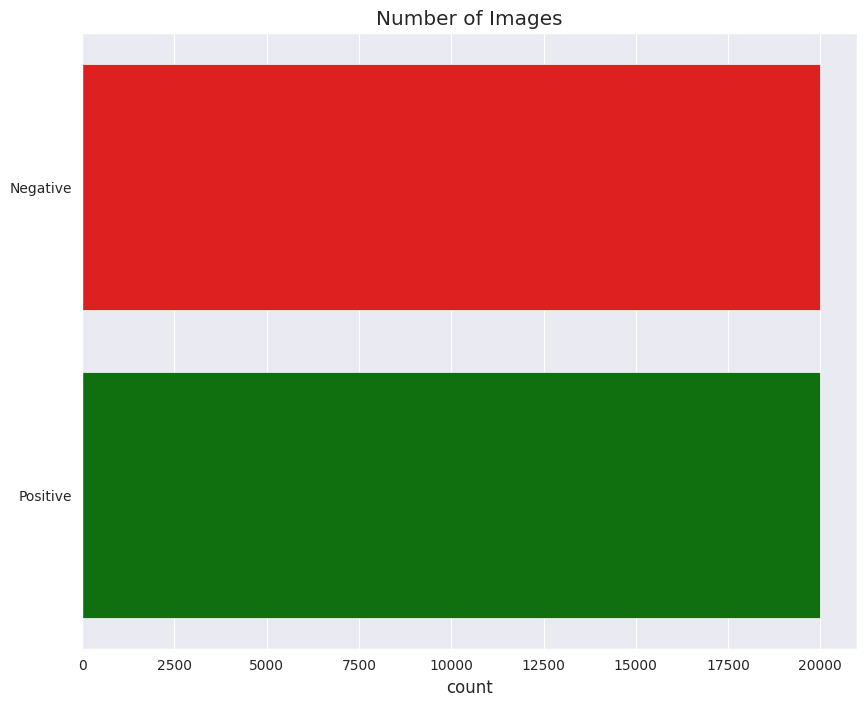

In [34]:
Im = []
for label_value in Dataset[1]:
    if label_value == 0:
        Im.append("Negative")
    elif label_value == 1:
        Im.append("Positive")


plt.figure(figsize=(10, 8))
sns.set_style('darkgrid')

ax1 = sns.countplot(
    y=Im,
    hue=Im,
    palette={"Negative": "red", "Positive": "green"},
    legend=False
)

ax1.set_title("Number of Images")
plt.show()

(np.float64(-0.5), np.float64(119.5), np.float64(119.5), np.float64(-0.5))

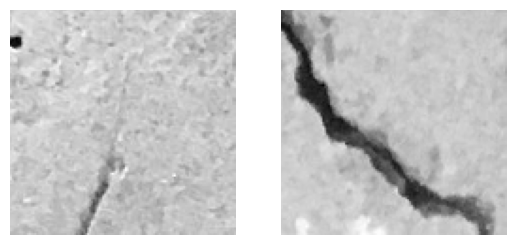

In [35]:
plt.subplot(1, 2, 1)
plt.imshow(X[1000].reshape(img_size, img_size), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(X[30000].reshape(img_size, img_size), cmap='gray')
plt.axis('off')

**VGG 16**

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense



model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(img_size,img_size,1)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 4
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 5
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Classifier
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dense(4096, activation='relu'))
model.add(Dense(1000, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 120, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    18,878,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,470,312 (207.79 MB)

 Trainable params: 54,470,312 (207.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-5)

model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

history = model.fit(X, y, epochs = 10 , batch_size = 128, validation_split = 0.25, verbose=1)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 222s 755ms/step - accuracy: 0.7021 - loss: 1.4357 - val_accuracy: 0.9469 - val_loss: 0.1621
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 142s 606ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9716 - val_loss: 0.0987
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 142s 607ms/step - accuracy: 0.9908 - loss: 0.0305 - val_accuracy: 0.9801 - val_loss: 0.0606
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 607ms/step - accuracy: 0.9941 - loss: 0.0197 - val_accuracy: 0.9911 - val_loss: 0.0297
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 607ms/step - accuracy: 0.9949 - loss: 0.0144 - val_accuracy: 0.9933 - val_loss: 0.0191
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 607ms/step - accuracy: 0.9956 - loss: 0.0140 - val_accuracy: 0.9898 - val_loss: 0.0291
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 607ms/step - accuracy: 0.9967 - loss: 0.0103 - val_accuracy: 0.9964 - val_loss: 0.0111
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 607ms/step - accuracy: 0.9974 -

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


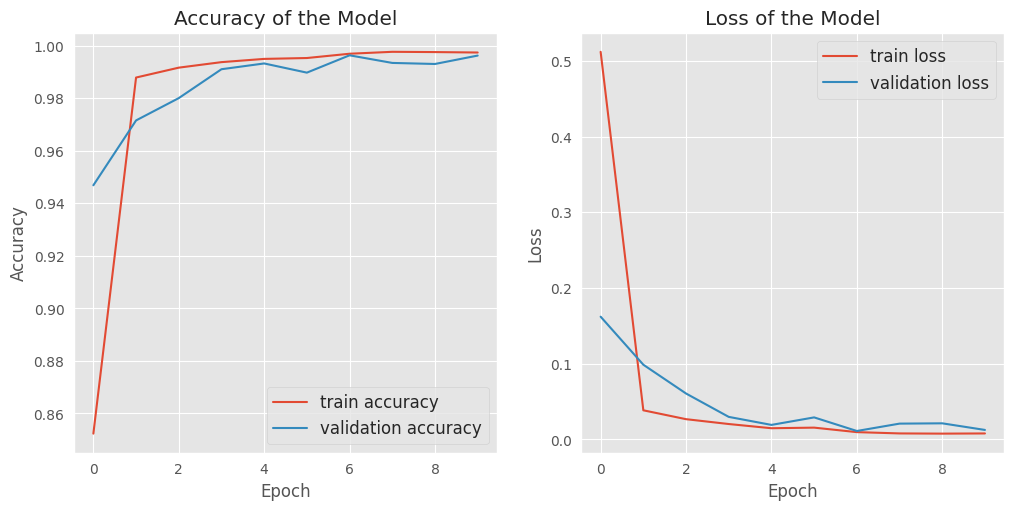

In [ ]:
plt.figure(figsize=(12, 12))
plt.style.use('ggplot')
plt.subplot(2,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy of the Model')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right', prop={'size': 12})

plt.subplot(2,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss of the Model')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train loss', 'validation loss'], loc='best', prop={'size': 12})

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

predictions = np.argmax(model.predict(X), axis=1)
print(classification_report(y, predictions, target_names = ['Negative','Positive']))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 51ms/step
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00     20000
    Positive       1.00      1.00      1.00     20000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



**VGG-19**

In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense




model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(img_size,img_size,1)))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 4
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Block 5
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dense(4096, activation='relu'))
model.add(Dense(len(labels), activation='softmax')) # Updated to match number of classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming X and y are already loaded
# Let's split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (30000, 120, 120, 1)
Shape of X_val: (10000, 120, 120, 1)
Shape of y_train: (30000,)
Shape of y_val: (10000,)


In [ ]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-5)

model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

history = model.fit(X, y, epochs = 10 , batch_size = 128, validation_split = 0.25, verbose=1)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 234s 770ms/step - accuracy: 0.8635 - loss: 0.2763 - val_accuracy: 0.9410 - val_loss: 0.1693
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 143s 609ms/step - accuracy: 0.9891 - loss: 0.0355 - val_accuracy: 0.9822 - val_loss: 0.0512
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 611ms/step - accuracy: 0.9944 - loss: 0.0168 - val_accuracy: 0.9782 - val_loss: 0.0562
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 612ms/step - accuracy: 0.9960 - loss: 0.0126 - val_accuracy: 0.9937 - val_loss: 0.0198
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 612ms/step - accuracy: 0.9970 - loss: 0.0085 - val_accuracy: 0.9909 - val_loss: 0.0287
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 612ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 0.9951 - val_loss: 0.0172
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 612ms/step - accuracy: 0.9981 - loss: 0.0076 - val_accuracy: 0.9973 - val_loss: 0.0112
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 612ms/step - accuracy: 0.9989 -

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


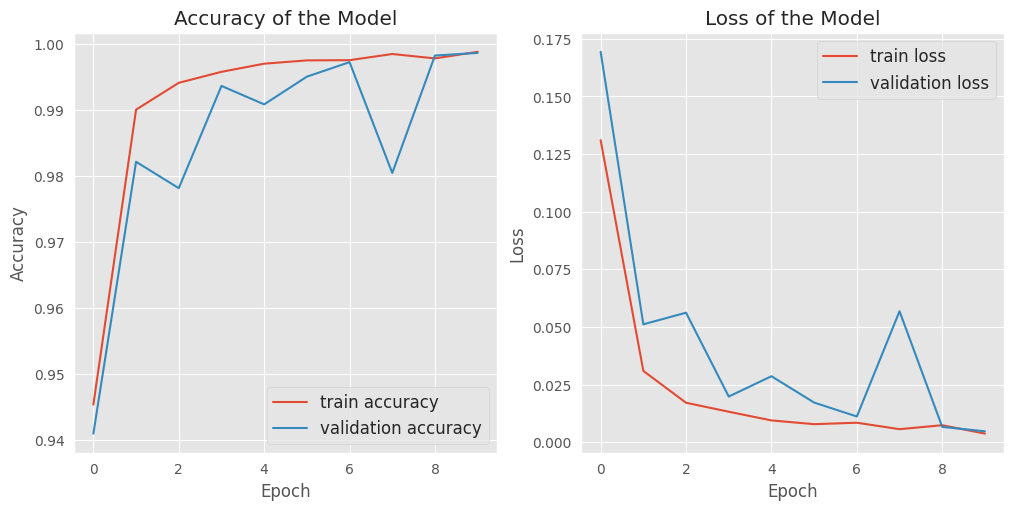

In [ ]:
plt.figure(figsize=(12, 12))
plt.style.use('ggplot')
plt.subplot(2,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy of the Model')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right', prop={'size': 12})

plt.subplot(2,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss of the Model')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train loss', 'validation loss'], loc='best', prop={'size': 12})

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

predictions = np.argmax(model.predict(X), axis=1)
print(classification_report(y, predictions, target_names = ['Negative','Positive']))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 54ms/step
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00     20000
    Positive       1.00      1.00      1.00     20000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



**MobileNet V2**

In [39]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.layers import Lambda
import tensorflow as tf

# Define the input layer matching your image dimensions
input_tensor = Input(shape=(img_size, img_size, 1))

# Load MobileNetV2 with pre-trained weights (excluding the top classification layer)
# Setting include_top=False allows for custom input shapes and channel counts
base_model = MobileNetV2(
    input_shape=(img_size, img_size, 3), # MobileNetV2 expects 3 channels for imagenet weights
    include_top=False,
    weights='imagenet' # Load ImageNet weights for feature extraction
)

# To use a 1-channel input with a 3-channel pretrained model, we need to convert the grayscale to 3 channels.
# A common way is to repeat the single channel three times.
# We will handle this by creating a simple wrapper around the base_model
# and explicitly converting grayscale to RGB before feeding to MobileNetV2.

# Create a Keras functional model for the grayscale to RGB conversion and then apply MobileNetV2
# First, a layer to convert 1-channel grayscale to 3-channel pseudo-RGB
# Using a Lambda layer for simple channel replication

def grayscale_to_rgb(x):
    # Replicate the single channel three times to create a pseudo-RGB image
    return tf.image.grayscale_to_rgb(x)

# Input for our model (120, 120, 1)
inputs = Input(shape=(img_size, img_size, 1))

# Convert grayscale to 3-channel pseudo-RGB
rgb_inputs = Lambda(grayscale_to_rgb)(inputs)

# Pass the pseudo-RGB inputs to the pre-trained MobileNetV2 base model
x = base_model(rgb_inputs)

# Add custom classification layers on top
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x) # Original example dense layer

# Adding the layers from the erroneous cell here
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(len(labels), activation='softmax')(x) # Output layer for 2 classes

model = Model(inputs=inputs, outputs=predictions)

# Freeze the layers of the base model to prevent retraining them
for layer in base_model.layers:
    layer.trainable = False

model.summary()

/tmp/ipython-input-34738974.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 120, 120, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,865,282 (14.74 MB)

 Trainable params: 1,607,298 (6.13 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
x = Dense(256, activation='relu')(inputs)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

In [18]:
from tensorflow.keras import regularizers

x = Dense(
    256,
    activation='relu',
    kernel_regularizer=regularizers.l2(1e-4)
)(inputs)

In [19]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-5)

model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

history = model.fit(X, y, epochs = 20 , batch_size = 128, validation_split = 0.25, verbose=1)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 53s 147ms/step - accuracy: 0.7768 - loss: 0.4807 - val_accuracy: 0.9691 - val_loss: 0.0866
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9760 - loss: 0.0826 - val_accuracy: 0.9783 - val_loss: 0.0594
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9862 - loss: 0.0469 - val_accuracy: 0.9800 - val_loss: 0.0567
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9882 - loss: 0.0388 - val_accuracy: 0.9832 - val_loss: 0.0480
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9908 - loss: 0.0301 - val_accuracy: 0.9830 - val_loss: 0.0499
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.9909 - loss: 0.0317 - val_accuracy: 0.9839 - val_loss: 0.0488
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9917 - loss: 0.0282 - val_accuracy: 0.9862 - val_loss: 0.0434
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9931 - loss: 0.0248 - val

In [20]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


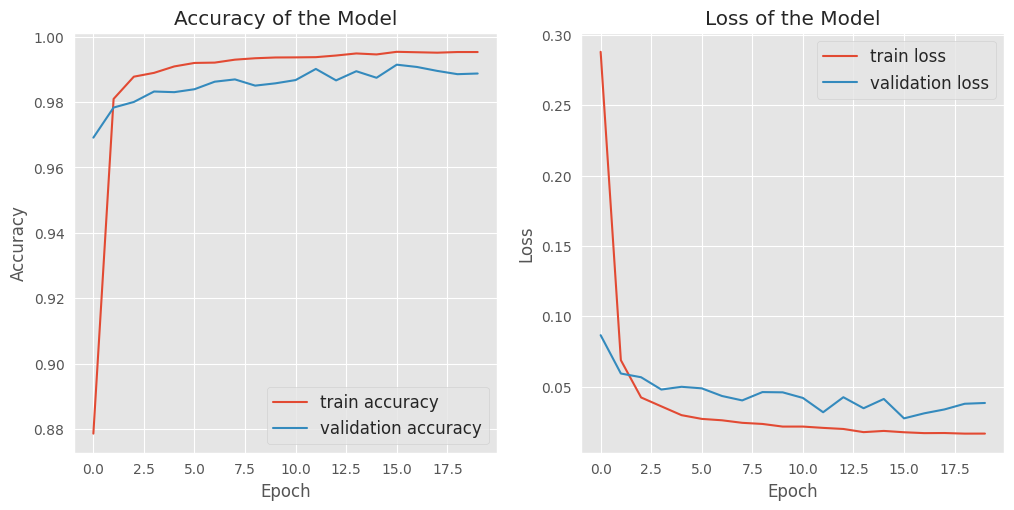

In [21]:
plt.figure(figsize=(12, 12))
plt.style.use('ggplot')
plt.subplot(2,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy of the Model')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right', prop={'size': 12})

plt.subplot(2,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss of the Model')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train loss', 'validation loss'], loc='best', prop={'size': 12})

**ResNet50**

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models


def conv_bn_relu(x, filters, kernel_size, strides=1, padding="same", name=None):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding=padding,
        use_bias=False,
        name=None if name is None else name + "_conv",
    )(x)
    x = layers.BatchNormalization(
        axis=-1, name=None if name is None else name + "_bn"
    )(x)
    x = layers.Activation(
        "relu", name=None if name is None else name + "_relu"
    )(x)
    return x


def bottleneck_block(x, filters, stride=1, conv_shortcut=False, name=None):
    """Bottleneck residual block for ResNet-50."""
    shortcut = x

    # shortcut branch
    if conv_shortcut:
        shortcut = layers.Conv2D(
            4 * filters, 1, strides=stride, use_bias=False,
            name=None if name is None else name + "_0_conv",
        )(shortcut)
        shortcut = layers.BatchNormalization(
            axis=-1, name=None if name is None else name + "_0_bn"
        )(shortcut)

    # main branch
    x = layers.Conv2D(
        filters, 1, strides=stride, use_bias=False,
        name=None if name is None else name + "_1_conv",
    )(x)
    x = layers.BatchNormalization(
        axis=-1, name=None if name is None else name + "_1_bn"
    )(x)
    x = layers.Activation("relu", name=None if name is None else name + "_1_relu")(x)

    x = layers.Conv2D(
        filters, 3, padding="same", use_bias=False,
        name=None if name is None else name + "_2_conv",
    )(x)
    x = layers.BatchNormalization(
        axis=-1, name=None if name is None else name + "_2_bn"
    )(x)
    x = layers.Activation("relu", name=None if name is None else name + "_2_relu")(x)

    x = layers.Conv2D(
        4 * filters, 1, use_bias=False,
        name=None if name is None else name + "_3_conv",
    )(x)
    x = layers.BatchNormalization(
        axis=-1, name=None if name is None else name + "_3_bn"
    )(x)

    # add & relu
    x = layers.Add(name=None if name is None else name + "_add")([shortcut, x])
    x = layers.Activation("relu", name=None if name is None else name + "_out")(x)
    return x


def ResNet50_keras(input_shape=(224, 224, 3), num_classes=1000):
    img_input = layers.Input(shape=input_shape)

    # ----- Stem -----
    x = layers.Conv2D(
        64, 7, strides=2, padding="same", use_bias=False, name="conv1_conv"
    )(img_input)
    x = layers.BatchNormalization(axis=-1, name="conv1_bn")(x)
    x = layers.Activation("relu", name="conv1_relu")(x)
    x = layers.MaxPooling2D(3, strides=2, padding="same", name="pool1_pool")(x)

    # ----- Stage 2 -----
    x = bottleneck_block(x, 64, stride=1, conv_shortcut=True, name="conv2_block1")
    x = bottleneck_block(x, 64, stride=1, conv_shortcut=False, name="conv2_block2")
    x = bottleneck_block(x, 64, stride=1, conv_shortcut=False, name="conv2_block3")

    # ----- Stage 3 -----
    x = bottleneck_block(x, 128, stride=2, conv_shortcut=True, name="conv3_block1")
    x = bottleneck_block(x, 128, name="conv3_block2")
    x = bottleneck_block(x, 128, name="conv3_block3")
    x = bottleneck_block(x, 128, name="conv3_block4")

    # ----- Stage 4 -----
    x = bottleneck_block(x, 256, stride=2, conv_shortcut=True, name="conv4_block1")
    x = bottleneck_block(x, 256, name="conv4_block2")
    x = bottleneck_block(x, 256, name="conv4_block3")
    x = bottleneck_block(x, 256, name="conv4_block4")
    x = bottleneck_block(x, 256, name="conv4_block5")
    x = bottleneck_block(x, 256, name="conv4_block6")

    # ----- Stage 5 -----
    x = bottleneck_block(x, 512, stride=2, conv_shortcut=True, name="conv5_block1")
    x = bottleneck_block(x, 512, name="conv5_block2")
    x = bottleneck_block(x, 512, name="conv5_block3")

    # ----- Head -----
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = models.Model(img_input, x, name="ResNet50")
    return model


if __name__ == "__main__":
    model = ResNet50_keras(input_shape=(img_size,img_size,1), num_classes=1000)
    model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 60, 60,    │      3,136 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 60, 60,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 60, 60,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 30, 30,    │          0 │ conv1_relu[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 30, 30,    │      4,096 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 30, 30,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 30, 30,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 30, 30,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 30, 30,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 30, 30,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 30, 30,    │     16,384 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 30, 30,    │     16,384 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 30, 30,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 30, 30,    │      1,024 │ conv2_block1_3_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_add    │ (None, 30, 30,    │          0 │ conv2_block1_0_b… │
│ (Add)               │ 256)              │            │ conv2_block1_3_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 30, 30,    │          0 │ conv2_block1_add

 Total params: 25,603,880 (97.67 MB)

 Trainable params: 25,550,760 (97.47 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [20]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=51e-4)

model.compile(loss="sparse_categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

history = model.fit(X, y, epochs = 10 , batch_size = 128, validation_split = 0.25, verbose=1)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 438ms/step - accuracy: 0.9483 - loss: 0.7890 - val_accuracy: 0.9755 - val_loss: 0.2296
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 80s 341ms/step - accuracy: 0.9908 - loss: 0.0314 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 346ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9971 - val_loss: 0.0182
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.9957 - val_loss: 0.0156
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - accuracy: 0.9978 - loss: 0.0079 - val_accuracy: 0.9869 - val_loss: 0.0408
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - accuracy: 0.9975 - loss: 0.0085 - val_accuracy: 0.9504 - val_loss: 0.1602
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 348ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9970 - val_loss: 0.0092
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 349ms/step - accuracy: 0.9981 - lo

In [21]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


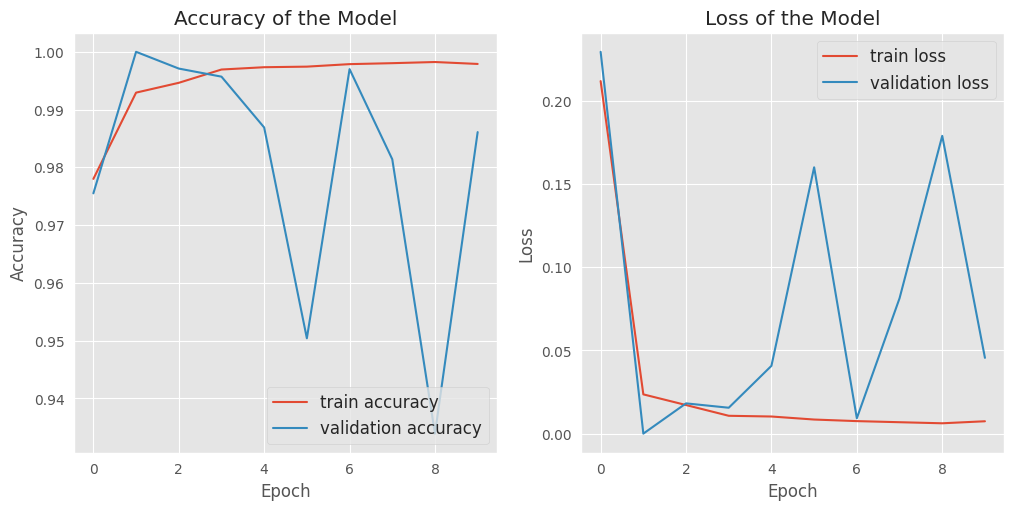

In [22]:
plt.figure(figsize=(12, 12))
plt.style.use('ggplot')
plt.subplot(2,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy of the Model')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right', prop={'size': 12})

plt.subplot(2,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss of the Model')
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['train loss', 'validation loss'], loc='best', prop={'size': 12})